In [1]:
%pip install pandas torch transformers deepparse huggingface_hub matplotlib ipympl rdflib sentence_transformers numpy
# Add Qwen optimization dependencies
%pip install flash-linear-attention causal-conv1d
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
if torch.cuda.is_available():
    print("CUDA - available devices:")
    for i in range(torch.cuda.device_count()):
        print(f"  {i}: {torch.cuda.get_device_name(i)}")
    device = torch.device('cuda')
elif torch.accelerator.is_available(): # Support other hardware accelators
    device = torch.accelerator.current_accelerator()
else:
    print("WARNING: Running on CPU")
    device = torch.device('cpu')
print(f"Torch version: {torch.__version__}, Device: {device}")

CUDA - available devices:
  0: NVIDIA A100 80GB PCIe
  1: NVIDIA A100 80GB PCIe
Torch version: 2.10.0+cu128, Device: cuda


In [3]:
from huggingface_hub import notebook_login
notebook_login()

In [4]:
from collections import OrderedDict
import pandas as pd
import json

ENTITIES_TO_PREDICT = [
    "HouseNumber",
    "StreetName",
    "Neighborhood",
    "City",
    "State",
    "District",
    "Country"
]

csv_read_args = dict(keep_default_na=False, dtype=str, na_values=[""])

bzkopen_train = pd.read_csv("open_data/bzkopen_addresses_train.csv", **csv_read_args)
bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv", **csv_read_args)
bzkopen_test = pd.read_csv("open_data/bzkopen_addresses_test.csv", **csv_read_args)

ALL_ENTITY_TYPES = [
    "UnitNumber",
    "HouseNumber",
    "StreetName",
    "Neighborhood",
    "City",
    "District",
    "Region",
    "State",
    "Country",
    "PostalCode"
]


In [5]:
import datetime
split_lengths = pd.DataFrame({
    "Number of Cards" : {"train":361, "val": 77, "test": 78},
    "Number of Addresses" : {"train": len(bzkopen_train), "val": len(bzkopen_val), "test": len(bzkopen_test)},
})
split_lengths["Proportion of Cards"] = split_lengths["Number of Cards"] / split_lengths["Number of Cards"].sum()
split_lengths["Proportion of Addresses"] = split_lengths["Number of Addresses"] / split_lengths["Number of Addresses"].sum()
split_lengths.loc["Total"] = split_lengths.sum()
split_lengths["Addresses per Card"] = split_lengths["Number of Addresses"] / split_lengths["Number of Cards"]
split_lengths = split_lengths[["Number of Cards", "Proportion of Cards", "Number of Addresses", "Proportion of Addresses", "Addresses per Card"]]
display(split_lengths.style.format("{:.0f}", subset=["Number of Cards", "Number of Addresses"]).format("{:.2%}", subset=["Proportion of Cards", "Proportion of Addresses"]))
estimated_total_addresses = 2_000_000 * split_lengths.at["Total", "Addresses per Card"]
print(f"Estimated total addresses in the dataset: {estimated_total_addresses:,.0f}")

def format_time(seconds, round_to_seconds=True):
    seconds = round(seconds) if round_to_seconds else seconds
    timedelta = datetime.timedelta(seconds=seconds)
    days = timedelta.days
    months, days = divmod(days, 30)
    years, months = divmod(months, 12)
    timedelta = timedelta - datetime.timedelta(days=timedelta.days) + datetime.timedelta(days=days)
    sb = []
    if years > 0:
        sb.append(f"{years} year{'s' if years > 1 else ''}")
    if months > 0:
        sb.append(f"{months} month{'s' if months > 1 else ''}")
    sb.append(f"{timedelta}")
    return ", ".join(sb)

,Number of Cards,Proportion of Cards,Number of Addresses,Proportion of Addresses,Addresses per Card
train,361,69.96%,771,70.67%,2.135734
val,77,14.92%,152,13.93%,1.974026
test,78,15.12%,168,15.40%,2.153846
Total,516,100.00%,1091,100.00%,2.114341


Estimated total addresses in the dataset: 4,228,682


In [6]:

FIXED_EXAMPLES = [
    ("Berlin, Alexanderplatz 1, 10178", 
     OrderedDict([("City" , "Berlin"), ("StreetName", "Alexanderplatz"), ("HouseNumber", "1")])),
    ("Braunschweig, Uferstr. 25", # From BZK open training set
     OrderedDict([("City", "Braunschweig"), ("StreetName", "Uferstr."), ("HouseNumber", "25")])),
    ("808 Westend Avenue, New York 25, N.Y.", # From BZK open training set
        OrderedDict([("StreetName", "Westend Avenue"), ("HouseNumber", "808"), 
        ("City", "New York"), ("State", "N.Y.")])),
]



In [ ]:

from modules.llms import JsonDictPromptTemplate, JSONTuplesPromptTemplate


PROMPTS = [
    JsonDictPromptTemplate("Segment addresses into their components.\n"
    "Output only a JSON object with the following keys: " + ", ".join(ENTITIES_TO_PREDICT) + ". "
    "Do not include fields that cannot be determined and do not try to guess their values. "
    "For example, if the address is simply \"Berlin\" then the field \"Country\" should be null. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n%(examples)s"
    "Now segment the following address:\n%(address)s"),

    JSONTuplesPromptTemplate("Annotate address components with the respective types. "
    "Consider the component types: " + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "Not all addresses will contain all component types and you must not guess the missing ones. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Output only a JSON list of [component, type] tuples.\n%(examples)s"
    "Now annotate the following address:\n%(address)s"),

    JsonDictPromptTemplate("You are a german archivist handling the digitalization of german documents from the "
    "compensation efforts that followed the second world war. Your current task consists of annotating addresses found "
    "in the archival documents, identifying the respective components of each address. "
    "Consider the component types: " + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "It is essential that you remain loyal to the original text and do not add any information not "
    "explictly mentioned in the address. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german. The addresses may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\", \"avenue\" or its abbreviation \"str.\" and \"av.\" for street.\n" # TODO Include Kreis (means district)
    "These terms may occur as a suffix to another word.\n"
    "Format the output as a JSON object with the component types as keys.\n%(examples)s" # TODO Include edge case examples
    "Now annotate the following address:\n%(address)s"),

    JSONTuplesPromptTemplate("You are a german archivist handling the digitalization of german documents from the "
    "compensation efforts that followed the second world war. Your current task consists of annotating addresses found "
    "in the archival documents, identifying the respective components of each address. "
    "Consider the component types: " + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "It is essential that you remain loyal to the original text and do not add any information not "
    "explictly mentioned in the address. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german. The addresses may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\", \"avenue\" or its abbreviation \"str.\" and \"av.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Format the output as a JSON list of [component, type] tuples.\n%(examples)s"
    "Now annotate the following address:\n%(address)s"),
    
    JSONTuplesPromptTemplate(
"""
## Task
You are an expert in address parsing and historical geography.
Your task is to annotate historical addresses by identifying and extracting their components.

Each extracted component must be classified into one of the following types:""" +
", ".join(ENTITIES_TO_PREDICT + ["Other"]) +
"""
---

## Annotation Rules

### General Rules
- Only extract information **explicitly present in the address**.
- Addresses may contain German or historical abbreviations and terms that indicate specific address components. Use these indicators to help classify the correct component.
  (e.g., straße/str., avenue/av. for streets; Krs. or Bez. for districts; Nr. or Haus-Nr. for house numbers; burg or stadt as part of city names).
- Do **not infer missing components**.
- Do **not modify spellings** from the original address.
- If uncertain about a component type, return NaN.

---

### City 
1. **Composite city names**
   - If a city is written as a compound name (e.g., Berlin-Marienfelde), extract **only the main city name**.

2. **Neighborhoods or regions**
   - Neighborhoods, boroughs, or regions should **not be classified as cities**.

3. **City qualifiers**
   - Do **not extract additional qualifiers or regional suffixes** attached to cities.

---

### State 
Do not classify the following as a state:
- components preceded by district indicators (e.g., Krs. for Kreis)
- historical regions (e.g., Böhmen)
- postal districts (e.g., London N.W.)
- geographical regions (e.g., L.I.)
- big cities (e.g., Sydney)

---

### House Number 
1. Extract **only the numeric part** of the house number. Ignore prefixes such as **Nr.** or **Haus-Nr.**
2. Separate **HouseNumber** and **Unit** if both appear.

---

## Output Format
Return the output as a **JSON list of tuples**:

[component, type]

Example format:
```json
[
  ["Berlin", "City"],
  ["Kurfürstenstraße", "StreetName"],
  ["12", "HouseNumber"],
  ["Germany", "Country"]
]
```

---

## Examples
%(examples)s

---

## Instruction
Annotate the components of the following address according to the rules above.

Address:
%(address)s
"""
),

    JsonDictPromptTemplate(
   "You are a German archivist handling the digitalization of German documents "
   "from the compensation efforts that followed the Second World War. "
   "Your current task consists of annotating addresses found in the archival documents, "
   "identifying the respective components of each address. Consider the component types: "
                            + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "It is essential that you remain loyal to the original text. "
    "Do not add any information not explicitly mentioned in the address, and do not correct any spelling.\n"
    "When interpreting the addresses, take into consideration:\n"
    "- Addresses will often be written in German, meaning country and city names may be in German.\n"
    "- City names may be connected together with a neighborhood name by a dash. Separate them accordingly.\n"
    "- Addresses in Israel will often have words in Hebrew.\n"
    "- It is likely that the address was written down by a German person who might "
    "have interpreted the phonetics of the words differently. "
    "Therefore, \"J\" might take the place of an \"I\" sound, \"W\" might take the place of a \"V\" sound, etc.\n"
    "The addresses often include terms such as:\n"
    "- \"burg\" or \"stadt\" for city\n"
    "- \"Kreis\" or \"Krs.\" for district\n"
    "- \"straße\", \"avenue\" or its abbreviations \"str.\" and \"av.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Format the output as a JSON object with the component types as keys.\n%(examples)s" # TODO Include edge case examples
    "Now annotate the following address:\n%(address)s"),

    JsonDictPromptTemplate(
   "You are a German archivist handling the digitalization of German documents "
   "from the compensation efforts that followed the Second World War. "
   "Your current task consists of annotating addresses found in the archival documents, "
   "identifying the respective components of each address. Consider the component types: "
                            + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "It is essential that you remain loyal to the original text. "
    "Do not add any information not explicitly mentioned in the address, and do not correct any spelling.\n"
    "When interpreting the addresses, take into consideration:\n"
    "- Addresses will often be written in German, meaning country and city names may be in German.\n"
    "- City names may be connected together with a neighborhood name by a dash. Separate them accordingly.\n"
    "- Addresses in Israel will often have words in Hebrew.\n"
    "The addresses often include terms such as:\n"
    "- \"burg\" or \"stadt\" for city\n"
    "- \"Kreis\" or \"Krs.\" for district\n"
    "- \"straße\", \"avenue\" or its abbreviations \"str.\" and \"av.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Format the output as a JSON object with the component types as keys.\n%(examples)s" # TODO Include edge case examples
    "Now annotate the following address:\n%(address)s"),
    
    JsonDictPromptTemplate(
   "You are a German archivist handling the digitalization of German documents "
   "from the compensation efforts that followed the Second World War. "
   "Your current task consists of annotating addresses found in the archival documents, "
   "identifying the respective components of each address. Consider the component types: "
                            + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "It is essential that you remain loyal to the original text. "
    "Do not add any information not explicitly mentioned in the address, and do not correct any spelling.\n"
    "When interpreting the addresses, take into consideration:\n"
    "- Addresses will often be written in German, meaning country and city names may be in German.\n"
    "- City names may be connected together with a neighborhood name by a dash. Separate them accordingly.\n"
    "- Addresses in Israel will often have words in Hebrew.\n"
    "- It is likely that the address was written down by a German person who might "
    "have interpreted the phonetics of the words differently. "
    "Therefore, \"J\" might take the place of an \"I\" sound, \"W\" might take the place of a \"V\" sound, etc.\n"
    "The addresses often include terms such as:\n"
    "- \"Kreis\" or \"Krs.\" for district\n"
    "- \"straße\", \"avenue\" or its abbreviations \"str.\" and \"av.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Format the output as a JSON object with the component types as keys.\n%(examples)s" # TODO Include edge case examples
    "Now annotate the following address:\n%(address)s"),

]





for i, prompt in enumerate(PROMPTS):
    print(f"Prompt {i}:")
    print(prompt.template)
    print()

Prompt 0:
Segment addresses into their components.
Output only a JSON object with the following keys: HouseNumber, StreetName, Neighborhood, City, State, District, Country. Do not include fields that cannot be determined and do not try to guess their values. For example, if the address is simply "Berlin" then the field "Country" should be null. Addresses will most times be written in german, meaning country and city names may be in german and the addresses may include german terms such as:
 - "burg" or "stadt" for city
 - "straße" or its abbreviation "str." for street.
These terms may occur as a suffix to another word.
%(examples)sNow segment the following address:
%(address)s

Prompt 1:
Annotate address components with the respective types. Consider the component types: HouseNumber, StreetName, Neighborhood, City, State, District, Country, Other. Not all addresses will contain all component types and you must not guess the missing ones. Addresses will most times be written in german, 

In [ ]:
from modules.deepparse_parser import DeepParseParser
from modules.libpostal_client import LibpostalClient
from modules.token_classifiers import TokenClassifierAddressParser
from modules.llms import (
    LLMAddressParsingModel, LlamaAddressParsingModel, QwenAddressParsingModel, 
    FixedExamples, ZeroShot, SimilarExamples
)
from itertools import combinations
import time
from pathlib import Path
import numpy as np
from modules.utils import compare_preds

model_configs = [
    {
        "name" : "libpostal",
        "factory": LibpostalClient,
        "cleanup": lambda client: client.close(),
        "family": "libpostal"
    },
    {
        "name" : "libpostal-expanded",
        "factory": LibpostalClient,
        "factory_kargs" : {"expand_before_parsing": True},
        "cleanup": lambda client: client.close(),
        "family": "libpostal"
    },
    {
        "name" : "deepparse-bpemb",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "device": device},
        "family": "deepparse"
    },
    {
        "name" : "deepparse-fasttext",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "device": device},
        "family": "deepparse"
    },
    {
        "name" : "deepparse-bpemb-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "attention_mechanism": True, "device": device},
        "family": "deepparse"
    },
    {
        "name" : "deepparse-fasttext-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "attention_mechanism": True, "device": device},
        "family": "deepparse"
    },
    {
        "name" : "xlm-roberta-large-address-parser", # from https://arxiv.org/abs/2404.05632
        "factory": TokenClassifierAddressParser,
        "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device},
        "family": "xlm-roberta"
    },
    {
        "name" : "xlm-roberta-large-address-parser-word-avg",
        "factory": TokenClassifierAddressParser,
        "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device, "aggregation_strategy": "average"},
        "family": "xlm-roberta"
    },
    {
        "name" : "xlm-roberta-large-address-parser-word-max",
        "factory": TokenClassifierAddressParser,
        "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device, "aggregation_strategy": "max"},
        "family": "xlm-roberta"
    }
]

LLAMA_MODELS = [
    ("Llama-3.2-1B", "meta-llama/Llama-3.2-1B-Instruct"),
    ("Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"),
    ("Llama-3-8B", "meta-llama/Meta-Llama-3-8B-Instruct"),
]


example_strategies = [
    ("0shot", ZeroShot()),
    ("fixed3shot", FixedExamples(FIXED_EXAMPLES))
]

for n in range(1, 5 + 1):
    example_strategies.append((f"similar{n}shot", {
        "factory" : SimilarExamples,
        "factory_kargs": dict(
            example_addresses=bzkopen_train["FullAddress"],
            example_labels=bzkopen_train,
            num_examples=n,
            labels_to_include=ENTITIES_TO_PREDICT,
            device=device
        )
    }))

MAIN_EXAMPLE_STRATEGIES = ["0shot", "similar5shot"]
MAIN_PROMPT_IDS = [2, 4, 5, 6, 7]

example_strategies_all_prompts = [example_strategy for example_strategy in example_strategies 
                                  if example_strategy[0] in MAIN_EXAMPLE_STRATEGIES]

def _make_llama_config(model_id, model_path, prompt_id, example_strategy_id, example_strategy):
        return {
            "name": f"{model_id}-prompt{prompt_id}-{example_strategy_id}",
            "factory": LlamaAddressParsingModel,
            "factory_kargs" : {
                "model_name": model_path,
                "prompt": PROMPTS[prompt_id],
                "example_strategy": example_strategy,
                "device": device
            },
            "family": "Llama"
        }

def _make_qwen_config(model_id, model_path, prompt_id, example_strategy_id, example_strategy):
    return {
        "name": f"{model_id}-prompt{prompt_id}-{example_strategy_id}",
        "factory": QwenAddressParsingModel,
        "factory_kargs" : {
            "model_name": model_path,
            "prompt": PROMPTS[prompt_id],
            "example_strategy": example_strategy,
            "device": device
        },
        "family": "Qwen"
    }

n_shot_model_configs = []
for model_id, model_name in LLAMA_MODELS:
    for example_strategy_id, example_strategy in example_strategies:
        for prompt_id in MAIN_PROMPT_IDS:
            llama_config = _make_llama_config(model_id, model_name, prompt_id, example_strategy_id, example_strategy)
            if example_strategy_id == "0shot":
                if model_id == "Llama-3-8B":
                    n_shot_model_configs.append(llama_config)
            elif isinstance(example_strategy, dict) and example_strategy.get("factory") == SimilarExamples:
                if model_id == "Llama-3-8B":
                    n_shot_model_configs.append(llama_config)
                elif example_strategy_id not in MAIN_EXAMPLE_STRATEGIES:
                    continue
            model_configs.append(llama_config)
    for prompt_id in range(len(PROMPTS)):
        for example_strategy_id, example_strategy in example_strategies_all_prompts:
            if prompt_id in MAIN_PROMPT_IDS: continue # Already included above
            model_configs.append(_make_llama_config(model_id, model_name, prompt_id, example_strategy_id, example_strategy))

thresh_similarity_configs = []
for thresh in []:# np.arange(-0.9, 1.0, 0.1):
    thresh_id = f"tresh{thresh:.1f}".replace(".", "p").replace("-", "m")
    example_strategy = {
        "factory" : SimilarExamples,
        "factory_kargs": dict(
            example_addresses=bzkopen_train["FullAddress"],
            example_labels=bzkopen_train,
            num_examples=10,
            labels_to_include=ENTITIES_TO_PREDICT,
            similarity_threshold=thresh,
            device=device
         )
    }
    llama_config = _make_llama_config("Llama-3-8B", "meta-llama/Meta-Llama-3-8B-Instruct", 
                                      2, f"{thresh_id}similarity10shot", example_strategy)
    thresh_similarity_configs.append(llama_config)
    model_configs.append(llama_config)

for prompt_id in MAIN_PROMPT_IDS:
    model_configs.append(
        _make_qwen_config("Qwen3.5-9B", "Qwen/Qwen3.5-9B", prompt_id, "similar5shot", {
            "factory" : SimilarExamples,
            "factory_kargs": dict(
                example_addresses=bzkopen_train["FullAddress"],
                example_labels=bzkopen_train,
                num_examples=n,
                labels_to_include=ENTITIES_TO_PREDICT,
                device=device
            )
        }))

assert len(model_configs) == len(set(config["name"] for config in model_configs)), "Duplicate model config names found!"

for config in model_configs:
    print(f"Model config: {repr(config)}")


Model config: {'name': 'libpostal', 'factory': <class 'libpostal_client.LibpostalClient'>, 'cleanup': <function <lambda> at 0x7f6ff86abe20>, 'family': 'libpostal'}
Model config: {'name': 'libpostal-expanded', 'factory': <class 'libpostal_client.LibpostalClient'>, 'factory_kargs': {'expand_before_parsing': True}, 'cleanup': <function <lambda> at 0x7f6d4340b7e0>, 'family': 'libpostal'}
Model config: {'name': 'deepparse-bpemb', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'device': device(type='cuda')}, 'family': 'deepparse'}
Model config: {'name': 'deepparse-fasttext', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'fasttext', 'device': device(type='cuda')}, 'family': 'deepparse'}
Model config: {'name': 'deepparse-bpemb-attention', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'attention_mechanism': True, 'device': device(type='cuda')}, 'family': 'd

In [9]:
import traceback

REPARSE_CONVERSATIONS = False
RERUN_CONFIGS = set(config["name"] for config in model_configs if "prompt5" in config["name"]) # set of config names to re-run even if cached predictions are available.

def eval(dataset, configs, cols_to_predict, pred_cache_path=None):
    if pred_cache_path is not None:
        pred_cache_path = Path(pred_cache_path)
    if pred_cache_path is None or not pred_cache_path.exists():
        cached_preds = {}
    else:
        print(f"Loading cached predictions...")
        with open(pred_cache_path, "r") as f:
            cached_preds = json.load(f)
    
    preds_per_config = []
    model_results = []

    for config in configs:
        config_name = config["name"]
        if (config_name in cached_preds) and not (config_name in RERUN_CONFIGS):
            print(f"Using cached predictions for model {config_name}... To avoid this delete or rename the file {pred_cache_path} or delete the entry for {config_name} inside it.")
            if issubclass(config.get("factory", None), LLMAddressParsingModel) and REPARSE_CONVERSATIONS:
                print("Re-parsing conversations")
                old_preds = cached_preds[config_name]["preds"]
                class FakeModel(config["factory"]):
                    def __init__(self, prompt):
                        self.prompt = prompt
                fake_model = FakeModel(config["factory_kargs"]["prompt"])
                preds = [
                    fake_model._parse_output(
                        json.loads(pred["fullConversation"]), 
                        original_address=address, 
                        example_metadata=pred.get("___example_metadata", None)
                    ) for pred, address in zip(old_preds, dataset["FullAddress"].tolist())
                ]
            else:
                preds = cached_preds[config_name]["preds"]
            deltatime = cached_preds[config_name]["deltatime"]
        else:
            try:
                print(f"Loading model {config_name}...")
                pargs = config.get("factory_pargs", [])
                kargs = config.get("factory_kargs", {})
                model = config["factory"](*pargs, **kargs)
                print(f"Segmenting addresses...")
                start = time.monotonic()
                preds = model.parse_addresses(dataset["FullAddress"].tolist())
                deltatime = time.monotonic() - start
                if "cleanup" in config:
                    print("Cleaning up model resources...")
                    config["cleanup"](model)
                print("Parsing model responses...")
                if pred_cache_path is not None:
                    cached_preds[config_name] = {
                        "preds": preds,
                        "deltatime": deltatime
                    }
                    with open(pred_cache_path, "w") as f:
                        json.dump(cached_preds, f)
            except Exception as e:
                print(f"Error while processing model {config_name}: {e}")
                traceback.print_exc()
                model_results.append({
                    "error" : len(dataset),
                    "errorRate" : 1.0
                })
                continue
        preds_df = pd.DataFrame(preds)
        preds_per_config.append(preds_df)
        print("Computing metrics...")
        metrics = compare_preds(preds_df, dataset[cols_to_predict], target_columns=cols_to_predict)
        metrics["deltatime"] = deltatime
        metrics["rate"] = len(dataset) / metrics["deltatime"]
        metrics["estimatedTotalTime"] = estimated_total_addresses / metrics["rate"]
        metrics["error"] = preds_df["error"].notna().sum() if "error" in preds_df.columns else 0
        metrics["errorRate"] = metrics["error"] / len(dataset)
        preds_df["config_name"] = config_name
        preds_df["FullAddress"] = dataset["FullAddress"]

        model_results.append(metrics)
        print(f"Results for model {config_name}: {metrics}")

    preds_per_config_df = pd.concat(preds_per_config)
    default_cols = ["config_name", "FullAddress"] + cols_to_predict
    new_order = default_cols + [col for col in preds_per_config_df.columns if col not in default_cols]
    preds_per_config_df = preds_per_config_df[new_order]

    results_df = pd.DataFrame(model_results, index = [config["name"] for config in configs])

    return preds_per_config_df, results_df

negative_metrics = ["errorRate", "deltatime", "estimatedTotalTime"]
skip_columns = ["errorRate"]

def col_best(col):
    if col.name in negative_metrics: return col.min()
    else: return col.max()

overall_best = None

def best_config_per_family(df):
    overall_best_configs = overall_best.index if overall_best is not None else []
    df = df.groupby(by={config["name"]:config.get("family", config["name"]) for config in model_configs}, sort=False).apply(
        lambda group: group.loc[
            [config for config in group.index 
             if config in overall_best_configs or any(
                 col_best(group[col]) == group.at[config, col] 
                 for col in group.columns 
                 if col not in skip_columns
                )]]
    )
    df = df.droplevel(0)
    return df

def bold_best(col):
    return ['font-weight: bold' if v == col_best(col) else '' for v in col]

preds_per_config, model_statistics = eval(
    bzkopen_val, model_configs, 
    [e for e in ENTITIES_TO_PREDICT if e not in ["Neighborhood", "District"]], 
    pred_cache_path="cached_preds_val.json"
)
overall_best = best_config_per_family(model_statistics[
    ["accuracy", "precision", "recall", "f1", "average_similarity", "errorRate", "estimatedTotalTime"]])
overall_best.style.apply(bold_best).format(format_time, subset=["estimatedTotalTime"])

Loading cached predictions...
Using cached predictions for model libpostal... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libpostal inside it.
Computing metrics...
Results for model libpostal: OrderedDict({'accuracy': 0.7368421052631579, 'precision': 0.6232558139534884, 'recall': 0.42138364779874216, 'f1': 0.5028142589118199, 'accuracy_with_tol_1': 0.7460526315789474, 'accuracy_with_tol_2': 0.7526315789473684, 'accuracy_with_tol_3': 0.7671052631578947, 'accuracy_with_tol_4': 0.7921052631578948, 'average_levenshtein': 2.0052631578947366, 'average_similarity': 0.7714431266162896, 'average_levenshtein_match': 2.45016077170418, 'average_similarity_match': 0.9425993186951448, 'no_match_rate': 0.18157894736842106, 'deltatime': 0.013871423900127411, 'rate': 10957.779179295636, 'estimatedTotalTime': 385.90686135860375, 'error': 0, 'errorRate': 0.0})
Using cached predictions for model libpostal-expanded... To avoid this delete or rename the file cached_

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Segmenting addresses...


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

MPNetModel LOAD REPORT from: sentence-transformers/multi-qa-mpnet-base-dot-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Segmenting addresses...


Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Parsing model responses...
Computing metrics...
Results for model Qwen3.5-9B-prompt7-similar5shot: OrderedDict({'accuracy': 0.9276315789473685, 'precision': 0.8738170347003155, 'recall': 0.8710691823899371, 'f1': 0.8724409448818897, 'accuracy_with_tol_1': 0.9355263157894737, 'accuracy_with_tol_2': 0.9447368421052632, 'accuracy_with_tol_3': 0.9486842105263158, 'accuracy_with_tol_4': 0.9565789473684211, 'average_levenshtein': 0.4644736842105263, 'average_similarity': 0.9430497061418114, 'average_levenshtein_match': 0.48356164383561645, 'average_similarity_match': 0.9818051735175023, 'no_match_rate': 0.03947368421052633, 'deltatime': 23.514926560223103, 'rate': 6.463979362670732, 'estimatedTotalTime': 654191.7808344403, 'error': 0, 'errorRate': 0.0})


,accuracy,precision,recall,f1,average_similarity,errorRate,estimatedTotalTime
libpostal,0.736842,0.623256,0.421384,0.502814,0.771443,0.000000,0:06:26
libpostal-expanded,0.739474,0.563559,0.418239,0.480144,0.798791,0.000000,0:21:53
deepparse-fasttext,0.481579,0.361314,0.311321,0.334459,0.548371,0.000000,0:30:00
xlm-roberta-large-address-parser-word-avg,0.818421,0.662116,0.610063,0.635025,0.852584,0.000000,4:52:45
xlm-roberta-large-address-parser-word-max,0.814474,0.659722,0.597484,0.627063,0.848050,0.000000,4:29:34
Llama-3.2-1B-prompt6-0shot,0.128947,0.172249,0.113208,0.136622,0.139418,0.000000,19:28:01
Llama-3.2-3B-prompt4-0shot,0.009211,1.000000,0.006289,0.012500,0.009211,0.000000,"4 days, 14:11:13"
Llama-3.2-3B-prompt4-fixed3shot,0.007895,1.000000,0.003145,0.006270,0.007895,0.000000,"5 days, 12:52:40"
Llama-3-8B-prompt6-similar4shot,0.930263,0.869159,0.877358,0.873239,0.942314,0.000000,"16 days, 10:28:21"
Llama-3-8B-prompt2-similar5shot,0.928947,0.864198,0.880503,0.872274,0.943585,0.000000,"1 month, 7 days, 2:23:50"


In [10]:
#train_preds_per_config, model_train_statistics = eval(bzkopen_train, model_configs, ENTITIES_TO_PREDICT, pred_cache_path="cached_preds_train.json")
#display(best_config_per_family(model_train_statistics[
#    ["accuracy", "precision", "recall", "f1", "average_similarity", "errorRate", "estimatedTotalTime"]]).style.apply(bold_best).format(format_time, subset=["estimatedTotalTime"]))
#total_time = model_statistics["deltatime"].sum() + model_train_statistics["deltatime"].sum()
#print(f"Total evaluation time (train + val): {format_time(total_time)}")

In [11]:
split_dfs = {
    #"train" : {
    #    "stats" : model_train_statistics,
    #    "preds" : train_preds_per_config
    #},
    "val" : {
        "stats" : model_statistics,
        "preds" : preds_per_config
    }
}

In [12]:
#best_config_per_family(model_train_statistics[["accuracy", "f1"]].merge(
#    model_statistics[["accuracy", "f1"]],
#    left_index=True, right_index=True, suffixes=("_train", "_val")
#)).style.apply(bold_best)

In [13]:
preds_per_config

,config_name,FullAddress,HouseNumber,StreetName,City,State,Country,house,state_district,unit,...,"State""], // Abbreviation for ""Nordbaden",StreetNameSuffix,"Other""] // Note: ""Krs."" is likely an abbreviation for ""Kreis"", which means ""district"" or ""county"", but I've annotated it as ""Other","Other""], // Krs. is an abbreviation for ""Kreis","Other""], // Str. is an abbreviation for ""Straße","District""], // Note: ""Krs."" is an abbreviation for ""Kreis","Neighborhood""], // Note: ""Ob."" is an abbreviation for ""Obere","StreetName""], // Note: ""Str."" is an abbreviation for ""Straße",Neighborhood/District,"Other""], // assuming ""SE"
0,libpostal,"Regensburg, Königstr. 2/I",2/i,königstr.,NaN,NaN,NaN,regensburg,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,libpostal,Dortmund,NaN,NaN,dortmund,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,libpostal,"Nürnberg, Nibelungenstrasse 8",8,nibelungenstrasse,NaN,NaN,NaN,nürnberg,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,libpostal,Jöhlingen/Krs.Durlach/Baden.,NaN,NaN,NaN,NaN,NaN,jöhlingen/krs.durlach/baden.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,libpostal,"8 Burlington Road, Manchester 20/England.",8___20/england.,burlington road manchester,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,Qwen3.5-9B-prompt7-similar5shot,2114-79 St. Jackson Heights. N.Y. USA,2114-79,St.,NaN,N.Y.,USA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,Qwen3.5-9B-prompt7-similar5shot,Losone CSR,NaN,NaN,Losone,NaN,CSR,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,Qwen3.5-9B-prompt7-similar5shot,"1544, Union St., Brooklyn, 13 N.Y.",1544,Union St.,Brooklyn,N.Y.,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,Qwen3.5-9B-prompt7-similar5shot,Rum.,NaN,NaN,NaN,NaN,Rum.,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
def look_at_conversation(full_conversation):
    conversation = json.loads(full_conversation)[0]["generated_text"]
    try:
        for i, turn in enumerate(conversation):
            print(f"Turn {i} - Role: {turn['role']}")
            print(f"Content:\n{turn['content']}")
            print()
    except:
        print("Could not parse conversation, raw content:")
        print(conversation)
for _, row in preds_per_config[preds_per_config["config_name"].str.contains("Qwen")].sample(5).iterrows():
    look_at_conversation(row["fullConversation"])
    print("-" * 50)

Could not parse conversation, raw content:
<|im_start|>user
You are a German archivist handling the digitalization of German documents from the compensation efforts that followed the Second World War. Your current task consists of annotating addresses found in the archival documents, identifying the respective components of each address. Consider the component types: HouseNumber, StreetName, Neighborhood, City, State, District, Country, Other. It is essential that you remain loyal to the original text. Do not add any information not explicitly mentioned in the address, and do not correct any spelling.
When interpreting the addresses, take into consideration:
- Addresses will often be written in German, meaning country and city names may be in German.
- City names may be connected together with a neighborhood name by a dash. Separate them accordingly.
- Addresses in Israel will often have words in Hebrew.
- It is likely that the address was written down by a German person who might have

In [15]:
n_shot_config_names = [config["name"] for config in n_shot_model_configs]
threshold_config_names = [config["name"] for config in thresh_similarity_configs]
model_statistics_nshots = model_statistics[model_statistics.index.isin(n_shot_config_names)]
#train_model_statistics_nshots = model_train_statistics[model_train_statistics.index.isin(n_shot_config_names)]
model_statistics_thresh = model_statistics[model_statistics.index.isin(threshold_config_names)]
#train_model_statistics_thresh = model_train_statistics[model_train_statistics.index.isin(threshold_config_names)]

In [16]:
default_cols = ["config_name", "FullAddress"] + ENTITIES_TO_PREDICT
preds_vs_trues = preds_per_config[default_cols].merge(
    bzkopen_val[default_cols[1:]], on="FullAddress", suffixes=("_pred", "_true"), how="left")
preds_vs_trues = preds_vs_trues[["config_name", "FullAddress"] + [new_col for col in ENTITIES_TO_PREDICT for new_col in [f"{col}_pred", f"{col}_true"]]] # Order the columns for readability
preds_vs_trues

,config_name,FullAddress,HouseNumber_pred,HouseNumber_true,StreetName_pred,StreetName_true,Neighborhood_pred,Neighborhood_true,City_pred,City_true,State_pred,State_true,District_pred,District_true,Country_pred,Country_true
0,libpostal,"Regensburg, Königstr. 2/I",2/i,2/I,königstr.,Königstr.,NaN,NaN,NaN,Regensburg,NaN,NaN,NaN,NaN,NaN,NaN
1,libpostal,Dortmund,NaN,NaN,NaN,NaN,NaN,NaN,dortmund,Dortmund,NaN,NaN,NaN,NaN,NaN,NaN
2,libpostal,"Nürnberg, Nibelungenstrasse 8",8,8,nibelungenstrasse,Nibelungenstrasse,NaN,NaN,NaN,Nürnberg,NaN,NaN,NaN,NaN,NaN,NaN
3,libpostal,Jöhlingen/Krs.Durlach/Baden.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jöhlingen,NaN,NaN,NaN,Durlach,NaN,NaN
4,libpostal,"8 Burlington Road, Manchester 20/England.",8___20/england.,8,burlington road manchester,Burlington Road,NaN,NaN,NaN,Manchester,NaN,NaN,NaN,NaN,NaN,England
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15903,Qwen3.5-9B-prompt7-similar5shot,2114-79 St. Jackson Heights. N.Y. USA,2114-79,2114,St.,79 St.,Jackson Heights,Jackson Heights,NaN,N.Y.,N.Y.,NaN,NaN,NaN,USA,USA
15904,Qwen3.5-9B-prompt7-similar5shot,Losone CSR,NaN,NaN,NaN,NaN,NaN,NaN,Losone,Losone,NaN,NaN,NaN,NaN,CSR,CSR
15905,Qwen3.5-9B-prompt7-similar5shot,"1544, Union St., Brooklyn, 13 N.Y.",1544,1544,Union St.,Union St.,NaN,NaN,Brooklyn,Brooklyn,N.Y.,N.Y.,NaN,NaN,NaN,NaN
15906,Qwen3.5-9B-prompt7-similar5shot,Rum.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rum.,Rum.


In [17]:
prediction_errors = preds_per_config.melt(
    id_vars=["config_name", "FullAddress"],
    value_vars=ENTITIES_TO_PREDICT,
    var_name="Entity",
    value_name="PredictedValue"
).merge(
    bzkopen_val.melt(
        id_vars=["FullAddress"],
        value_vars=ENTITIES_TO_PREDICT,
        var_name="Entity",
        value_name="TrueValue"
    ),
    on=["FullAddress", "Entity"]
)
prediction_errors = prediction_errors[prediction_errors["PredictedValue"] != prediction_errors["TrueValue"]]
prediction_errors.dropna(subset=["PredictedValue", "TrueValue"], how="all", inplace=True)
prediction_errors

,config_name,FullAddress,Entity,PredictedValue,TrueValue
0,libpostal,"Regensburg, Königstr. 2/I",HouseNumber,2/i,2/I
4,libpostal,"8 Burlington Road, Manchester 20/England.",HouseNumber,8___20/england.,8
12,libpostal,"Berlin-Lichterfelde-Ost, Berlinerstr.48a (Alte...",HouseNumber,NaN,48a
24,libpostal,"Berlin-Marienfelde, Alt Marienfelde 4",HouseNumber,NaN,4
26,libpostal,20 Orchideenstieg 9.,HouseNumber,20___9,NaN
...,...,...,...,...,...
111086,Qwen3.5-9B-prompt6-similar5shot,Madiorban-Hedersch/Ung.,Country,NaN,Ung.
111108,Qwen3.5-9B-prompt6-similar5shot,"Nordheim/Krs. Heilbronn/N, Kelterstr. 37.",Country,N,NaN
111250,Qwen3.5-9B-prompt7-similar5shot,Madiorban-Hedersch/Ung.,Country,NaN,Ung.
111271,Qwen3.5-9B-prompt7-similar5shot,Nordheim/Krs. Heilbronn/N.,Country,N.,NaN


In [18]:

metric = "f1"
best_config_per_family(model_statistics[[metric]])


,f1
libpostal,0.502814
libpostal-expanded,0.480144
deepparse-fasttext,0.334459
xlm-roberta-large-address-parser-word-avg,0.635025
xlm-roberta-large-address-parser-word-max,0.627063
Llama-3.2-1B-prompt6-0shot,0.136622
Llama-3.2-3B-prompt4-0shot,0.012500
Llama-3.2-3B-prompt4-fixed3shot,0.006270
Llama-3-8B-prompt6-similar4shot,0.873239
Llama-3-8B-prompt2-similar5shot,0.872274


In [ ]:
from modules.utils import Aggregator
from collections import defaultdict

def get_n_shots(config):
    config_name = config["name"]
    config_prefix = "-".join([part for part in config_name.split("-") if not part.endswith("shot")])
    example_strategy = config.get("factory_kargs", {}).get("example_strategy")
    if isinstance(example_strategy, ZeroShot):
        return 0, config_prefix
    elif isinstance(example_strategy, FixedExamples):
        return len(example_strategy.examples), config_prefix
    elif isinstance(example_strategy, dict):
        if example_strategy.get("factory") == SimilarExamples:
            num_examples = example_strategy.get("factory_kargs", {}).get("num_examples")
            if num_examples is not None:
                return num_examples, config_prefix
    return None, None

config_prefixes = set(get_n_shots(config)[1] for config in n_shot_model_configs)
config_nshots = set(get_n_shots(config)[0] for config in n_shot_model_configs)

metric_per_shot = {
    (split, prefix) : defaultdict(Aggregator) for split in ["train", "val"] for prefix in config_prefixes
}

sim_per_shot = defaultdict(Aggregator)


for config in n_shot_model_configs:
    config_name = config["name"]
    n_shots, config_prefix = get_n_shots(config)
    assert n_shots is not None
    for meta in preds_per_config[preds_per_config["config_name"] == config_name]["___example_metadata"]:
        if isinstance(meta, list):
            sim_per_shot[n_shots].aggregate([hit["score"] for hit in meta])
    for split in ["val"]: #["train", "val"]:
        stats = split_dfs[split]["stats"]
        preds = split_dfs[split]["preds"]
        preds = preds[preds["config_name"] == config_name]
        metric_per_shot[(split, config_prefix)][n_shots].aggregate_single(stats.at[config_name, metric])
metric_per_shot = pd.DataFrame(
    data={
        idx : {col : agg.mean for col, agg in col_aggs.items()} 
        for idx, col_aggs in metric_per_shot.items()
    },
    columns=pd.MultiIndex.from_tuples(
        [(split, prefix) for prefix in config_prefixes for split in ["train", "val"]], 
        names=["split", "config_prefix"]
    ))
metric_per_shot.index.name = "n_shots"
if len(set(metric_per_shot.columns.get_level_values("config_prefix"))) != 1:
    for split in metric_per_shot.columns.get_level_values("split").unique():
        metric_per_shot[split, "mean"] = metric_per_shot[split].mean(axis=1)
metric_per_shot.columns = ['_'.join(col).strip('_') for col in metric_per_shot.columns]

sim_per_shot = pd.DataFrame(
    {
        stat : {nshot : getattr(agg, stat) for nshot, agg in sim_per_shot.items()} 
        for stat in ["mean", "max", "min"]
})

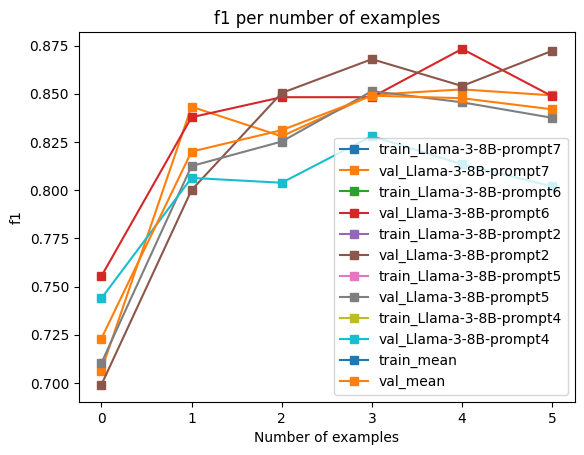

In [20]:
if len(metric_per_shot) > 0:
    metric_per_shot.plot(
        kind="line", marker="s", xticks=metric_per_shot.index,
        xlabel="Number of examples", ylabel=metric, 
        title=f"{metric} per number of examples"
    )

In [21]:
wrong_cities = preds_vs_trues[
    preds_vs_trues["config_name"].isin(["Qwen3.5-9B-prompt2-similar5shot", "Qwen3.5-9B-prompt5-similar5shot"])
][
    preds_vs_trues["City_true"].fillna("") != preds_vs_trues["City_pred"].fillna("")
][
["config_name", "FullAddress", "City_pred", "City_true"]
]
wrong_cities

/tmp/ipykernel_3374774/3139295199.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  wrong_cities = preds_vs_trues[


,config_name,FullAddress,City_pred,City_true
15105,Qwen3.5-9B-prompt2-similar5shot,Haspe-Hagen,Haspe-Hagen,Hagen
15133,Qwen3.5-9B-prompt2-similar5shot,Kolmar/Posen,NaN,Kolmar
15135,Qwen3.5-9B-prompt2-similar5shot,Weiler Krs. Schw. Gmünd,Gmünd,Weiler
15139,Qwen3.5-9B-prompt2-similar5shot,"Remscheid-Lennep, Ringstr. 123 / Kreis Remscheid",Remscheid-Lennep,Remscheid
15142,Qwen3.5-9B-prompt2-similar5shot,Rawitsch/Krs. Breslau,NaN,Rawitsch
15146,Qwen3.5-9B-prompt2-similar5shot,Madiorban-Hedersch/Ung.,Madiorban-Hedersch,Madiorban
15158,Qwen3.5-9B-prompt2-similar5shot,"Kfar Saba Machano Ognen, Israel",Kfar Saba,NaN
15172,Qwen3.5-9B-prompt2-similar5shot,Urfahr/Linz Österr. Gründberg 166,Urfahr/Linz,Linz
15198,Qwen3.5-9B-prompt2-similar5shot,Michelstadt/Odw.,Michelstadt/Odw.,Michelstadt
15202,Qwen3.5-9B-prompt2-similar5shot,Neuwied/Rh. Werftstr. 8,Neuwied/Rh.,Neuwied


In [22]:
for idx, row in wrong_cities.iterrows():
    full_conversation = preds_per_config[
        (preds_per_config["config_name"]==row["config_name"]) & 
        (preds_per_config["FullAddress"] == row["FullAddress"])
    ]["fullConversation"]
    for conv in full_conversation:
        print(look_at_conversation(conv))
        print("Expected city:", row["City_true"])

Could not parse conversation, raw content:
<|im_start|>user
You are a german archivist handling the digitalization of german documents from the compensation efforts that followed the second world war. Your current task consists of annotating addresses found in the archival documents, identifying the respective components of each address. Consider the component types: HouseNumber, StreetName, Neighborhood, City, State, District, Country, Other. It is essential that you remain loyal to the original text and do not add any information not explictly mentioned in the address. Addresses will most times be written in german, meaning country and city names may be in german. The addresses may include german terms such as:
 - "burg" or "stadt" for city
 - "straße", "avenue" or its abbreviation "str." and "av." for street.
These terms may occur as a suffix to another word.
Format the output as a JSON object with the component types as keys.
Consider the following examples:
Address: Hannover Hauff

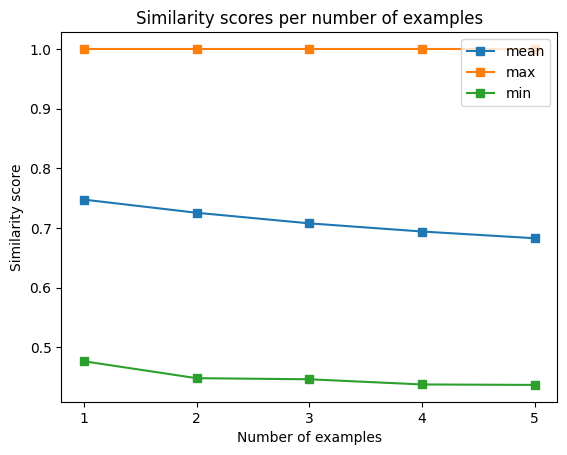

In [23]:
if len(sim_per_shot) > 0:
    sim_per_shot.plot(
        kind="line", marker="s", xticks=sim_per_shot.index,
        xlabel="Number of examples", ylabel="Similarity score", 
        title=f"Similarity scores per number of examples"
    )

In [24]:
def get_threshold(config):
    config_name = config["name"]
    config_prefix = "-".join([part for part in config_name.split("-") if not part.endswith("shot")])
    example_strategy = config.get("factory_kargs", {}).get("example_strategy")
    if isinstance(example_strategy, dict):
        if example_strategy.get("factory") == SimilarExamples:
            threshold = example_strategy.get("factory_kargs", {}).get("similarity_threshold")
            if threshold is not None:
                return threshold, config_prefix
    return None, None

metric_per_thresh = pd.DataFrame(columns=pd.MultiIndex.from_tuples(
    [(split, get_threshold(config)[1], config["name"]) 
     for config in thresh_similarity_configs for split in ["train", "val"]],
    names=["split", "config_prefix", "config_name"]
))
count_per_thresh = pd.DataFrame(index=metric_per_thresh.index, columns=metric_per_thresh.columns)


for config in thresh_similarity_configs:
    config_name = config["name"]
    threshold, config_prefix = get_threshold(config)
    assert threshold is not None
    for split in ["val"]: #["train", "val"]:
        stats = split_dfs[split]["stats"]
        preds = split_dfs[split]["preds"]
        metric_per_thresh.at[threshold, (split, config_prefix, config_name)] = stats.at[config_name, metric]
        config_preds = preds[preds["config_name"] == config_name]
        config_example_counts = config_preds["___example_metadata"].apply(lambda meta: sum((1 if hit["included"] else 0) for hit in meta))
        count_per_thresh.at[threshold, (split, config_prefix, config_name)] = config_example_counts.sum()

metric_per_thresh = metric_per_thresh.stack(level="config_name").groupby(level=0).mean()      
metric_per_thresh.index.name = None
if len(set(metric_per_thresh.columns.get_level_values("config_prefix"))) != 1:
    for split in metric_per_thresh.columns.get_level_values("split").unique():
        metric_per_thresh[split, "mean"] = metric_per_thresh[split].mean(axis=1)
metric_per_thresh.columns = ['_'.join(col).strip('_') for col in metric_per_thresh.columns]

In [25]:
if len(metric_per_thresh) > 0:
    metric_per_thresh.plot(
        kind="line", marker="s",
        xlabel="Similarity threshold", ylabel=metric, 
        title=f"{metric} per similarity threshold"
    )

In [26]:
metric_per_column = pd.DataFrame(index=model_statistics.index, columns=ENTITIES_TO_PREDICT)
for col in ENTITIES_TO_PREDICT:
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        if len(preds) == 0:
            print(f"No predictions found for config {config} and column {col}, skipping.")
            continue
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            metric_per_column.at[config, col] = value
        else:
            metric_per_column.at[config, col] = pd.NA
print(f"Per-column {metric} scores:")
metric_per_column = best_config_per_family(metric_per_column)
metric_per_column.style.apply(bold_best)


Per-column f1 scores:


,HouseNumber,StreetName,Neighborhood,City,State,District,Country
libpostal,0.666667,0.528926,0.000000,0.403587,0.666667,0.000000,0.466667
libpostal-expanded,0.719298,0.237288,0.000000,0.464135,0.250000,0.000000,0.608696
deepparse-bpemb,0.666667,0.026667,0.000000,0.257576,0.000000,0.000000,0.169492
deepparse-fasttext,0.612613,0.088235,0.000000,0.367647,0.000000,0.000000,0.272727
deepparse-bpemb-attention,0.225352,0.046875,0.000000,0.019048,0.000000,0.000000,0.180451
deepparse-fasttext-attention,0.413793,0.044444,0.000000,0.104803,0.000000,0.000000,0.231405
xlm-roberta-large-address-parser,0.806723,0.672000,0.000000,0.471014,0.117647,0.000000,0.765432
xlm-roberta-large-address-parser-word-avg,0.806723,0.715447,0.000000,0.520147,0.117647,0.000000,0.759494
xlm-roberta-large-address-parser-word-max,0.806723,0.721311,0.000000,0.505576,0.117647,0.000000,0.734177
Llama-3.2-1B-prompt6-0shot,0.211640,0.225352,0.000000,0.000000,0.000000,0.000000,0.000000


<Axes: title={'center': 'Val f1 per number of examples'}, xlabel='Number of examples', ylabel='f1'>

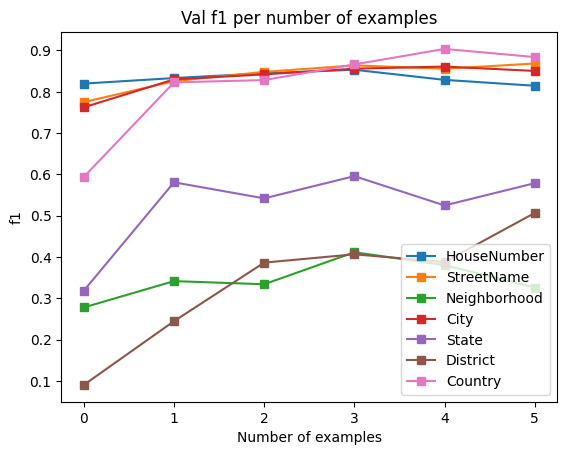

In [27]:
metric_per_column_per_shot = pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics_nshots.index, metric_per_shot.index]),
    columns=ENTITIES_TO_PREDICT
)
for col in ENTITIES_TO_PREDICT:
    for config in n_shot_model_configs:
        config_name = config["name"]
        preds = preds_per_config[preds_per_config["config_name"] == config_name]
        if len(preds) == 0:
            print(f"No predictions found for config {config_name} and column {col}, skipping.")
            continue
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            n_shots, model_name = get_n_shots(config)
            if n_shots is not None:
                metric_per_column_per_shot.at[(config_name, n_shots), col] = value
        else:
            metric_per_column_per_shot.at[(config_name, 0), col] = pd.NA

metric_per_column_per_shot = metric_per_column_per_shot.groupby(level=1).mean()
metric_per_column_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"Val {metric} per number of examples"
)

In [28]:
bzk_fields = bzkopen_val["field"].unique()
print(f"bzk_fields: {bzk_fields}")
metric_per_bzk_field = pd.DataFrame(index=model_statistics.index, columns=bzk_fields)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        if len(preds) == 0:
            print(f"No predictions found for config {config} and column {col}, skipping.")
            continue
        value = compare_preds(preds[mask], subset, target_columns=ENTITIES_TO_PREDICT)[metric]
        metric_per_bzk_field.at[config, field] = value
print(f"Per-BZK-field {metric} scores:")
metric_per_bzk_field = best_config_per_family(metric_per_bzk_field)
metric_per_bzk_field.style.apply(bold_best)

bzk_fields: <StringArray>
['ApplicantCurrentAddress',        'VictimBirthPlace',
    'VictimCurrentAddress',     'ApplicantBirthPlace',
        'VictimDeathPlace']
Length: 5, dtype: str
Per-BZK-field f1 scores:


,ApplicantCurrentAddress,VictimBirthPlace,VictimCurrentAddress,ApplicantBirthPlace,VictimDeathPlace
libpostal,0.455516,0.434783,0.440678,0.500000,0.545455
libpostal-expanded,0.390411,0.480000,0.355932,0.595420,0.800000
deepparse-fasttext,0.241830,0.571429,0.254237,0.380952,0.500000
xlm-roberta-large-address-parser-word-avg,0.554878,0.500000,0.656000,0.619718,0.909091
xlm-roberta-large-address-parser-word-max,0.554878,0.470588,0.645161,0.604317,0.909091
Llama-3.2-1B-prompt6-0shot,0.174603,0.000000,0.282828,0.000000,0.000000
Llama-3.2-3B-prompt4-0shot,0.000000,0.000000,0.000000,0.050000,0.000000
Llama-3.2-3B-prompt4-fixed3shot,0.000000,0.000000,0.028169,0.000000,0.000000
Llama-3-8B-prompt4-fixed3shot,0.778409,0.666667,0.691729,0.708333,1.000000
Llama-3-8B-prompt2-similar2shot,0.776536,0.838710,0.751880,0.802469,1.000000


<Axes: title={'center': 'Val f1 per number of examples'}, xlabel='Number of examples', ylabel='f1'>

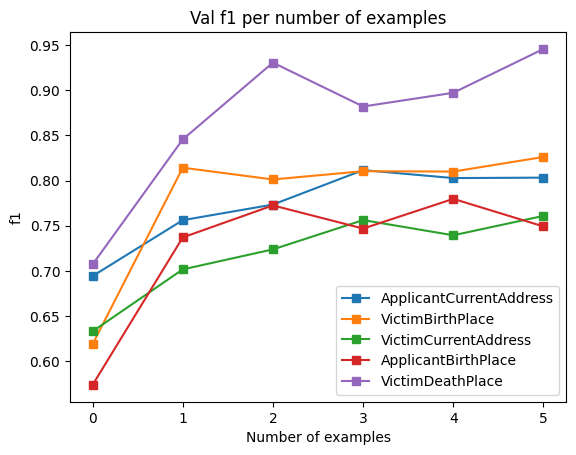

In [29]:
metric_per_bzk_field_per_shot =  pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics_nshots.index, metric_per_shot.index]),
    columns=bzk_fields
)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in n_shot_model_configs:
        config_name = config["name"]
        preds = preds_per_config[preds_per_config["config_name"] == config_name]
        if len(preds) == 0:
            print(f"No predictions found for config {config_name} and column {col}, skipping.")
            continue
        value = compare_preds(preds[mask], subset, target_columns=ENTITIES_TO_PREDICT)[metric]
        n_shots, model_name = get_n_shots(config)
        if n_shots is not None:
            metric_per_bzk_field_per_shot.at[(config_name, n_shots), field] = value

metric_per_bzk_field_per_shot = metric_per_bzk_field_per_shot.groupby(level=1).mean()
metric_per_bzk_field_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"Val {metric} per number of examples"
)